In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/maheshdattatreya
/kaggle/input/datasets/maheshdattatreya/research-qt-4
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage/Pepper__bell___Bacterial_spot
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage/Potato___healthy
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage/Tomato_Leaf_Mold
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus
/kaggle/inpu

In [4]:
!pip install -q tensorflow-model-optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 94.1 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.3

In [5]:
import tensorflow_model_optimization as tfmot

print("TFMOT loaded successfully")

TFMOT loaded successfully


**Cell 1: Imports**

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_model_optimization as tfmot
import os
import time

**Cell 2: Dataset Path**

In [9]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "archive (3)" in root:
        print(root)

/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage/Pepper__bell___Bacterial_spot
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage/Potato___healthy
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage/Tomato_Leaf_Mold
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus
/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage/PlantVillage/Tomato_Bacterial_spot
/kaggle/input/dat

In [10]:
dataset_path = "/kaggle/input/datasets/maheshdattatreya/research-qt-4/archive (3)/archive (3)/PlantVillage"

**Cell 3: Load Dataset**

In [11]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

Found 41276 files belonging to 16 classes.
Using 33021 files for training.


I0000 00:00:1780694694.420251      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780694694.426353      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 41276 files belonging to 16 classes.
Using 8255 files for validation.


**Cell 4: Dataset Optimization**

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

**Cell 5: Evaluation Function**

In [13]:
results = []

def evaluate_model(model, name):

    loss, accuracy = model.evaluate(
        val_ds,
        verbose=0
    )

    model.save(f"{name}.keras")

    size_mb = (
        os.path.getsize(f"{name}.keras")
        /(1024*1024)
    )

    params = model.count_params()

    for images, labels in val_ds.take(1):
        sample = images[:1]

    start = time.time()

    for _ in range(100):
        model.predict(sample, verbose=0)

    latency = (time.time()-start)/100

    energy = latency * 70 / 3600

    results.append([
        name,
        accuracy,
        params,
        size_mb,
        latency,
        energy
    ])

**Cell 6: Baseline EfficientNetB0**

In [14]:
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

teacher = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

teacher.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 [==============================] - 0s 0us/step


**Cell 7: Train Teacher**

In [15]:
teacher.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

evaluate_model(
    teacher,
    "Teacher_EfficientNetB0"
)

Epoch 1/3


E0000 00:00:1780694795.807374      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780694841.239022     166 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780694842.968010     165 service.cc:152] XLA service 0x7edb3c77cd40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780694842.968072     165 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780694842.968078     165 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


   1/1032 [..............................] - ETA: 15:12:29 - loss: 2.9112 - accuracy: 0.0312

I0000 00:00:1780694843.269383     165 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1032/1032 [==============================] - 133s 78ms/step - loss: 1.1411 - accuracy: 0.4887 - val_loss: 0.9852 - val_accuracy: 0.4915
Epoch 2/3
1032/1032 [==============================] - 79s 76ms/step - loss: 0.9688 - accuracy: 0.4917 - val_loss: 0.9544 - val_accuracy: 0.4766
Epoch 3/3
1032/1032 [==============================] - 79s 76ms/step - loss: 0.9370 - accuracy: 0.4955 - val_loss: 0.9652 - val_accuracy: 0.4667


**Cell 8: Pruning**

In [19]:
import tensorflow_model_optimization as tfmot

prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

pruning_params = {
    'pruning_schedule':
    tfmot.sparsity.keras.ConstantSparsity(
        target_sparsity=0.5,
        begin_step=0
    )
}

base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

pruned_model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),

    prune_low_magnitude(
        tf.keras.layers.Dense(
            len(class_names),
            activation='softmax'
        ),
        **pruning_params
    )
])

pruned_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Cell 9: Train Pruned Model**

In [20]:
callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep()
]

pruned_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2,
    callbacks=callbacks
)

evaluate_model(
    pruned_model,
    "Pruned_Model"
)

Epoch 1/2


E0000 00:00:1780695475.549008      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1032/1032 [==============================] - 88s 79ms/step - loss: 1.1925 - accuracy: 0.4890 - val_loss: 1.0272 - val_accuracy: 0.4951
Epoch 2/2
1032/1032 [==============================] - 79s 76ms/step - loss: 1.0091 - accuracy: 0.4932 - val_loss: 0.9776 - val_accuracy: 0.4886


**Cell 10: Quantization**

In [21]:
converter = tf.lite.TFLiteConverter.from_keras_model(
    teacher
)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

quantized_model = converter.convert()

with open(
    "quantized.tflite",
    "wb"
) as f:
    f.write(quantized_model)

INFO:tensorflow:Assets written to: /tmp/tmpvx85w2_l/assets


INFO:tensorflow:Assets written to: /tmp/tmpvx85w2_l/assets
W0000 00:00:1780695720.324722      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780695720.324814      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1780695720.594015      58 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


**Cell 11: Quantized Model Metrics**

In [23]:
quant_size = (
    os.path.getsize("quantized.tflite")
    /(1024*1024)
)

results.append([
    "Quantized_TFLite",
    np.nan,
    np.nan,
    quant_size,
    np.nan,
    np.nan
])

**Cell 12: Student Model (Knowledge Distillation Approximation)**

In [25]:
student_base = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

student_base.trainable = False

student = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),

    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    student_base,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

student.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Cell 13: Train Student**

In [26]:
student.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

evaluate_model(
    student,
    "Student_MobileNetV2"
)

Epoch 1/3
1032/1032 [==============================] - 56s 52ms/step - loss: 1.1562 - accuracy: 0.4830 - val_loss: 1.0866 - val_accuracy: 0.4749
Epoch 2/3
1032/1032 [==============================] - 52s 50ms/step - loss: 1.0080 - accuracy: 0.4875 - val_loss: 1.0281 - val_accuracy: 0.4560
Epoch 3/3
1032/1032 [==============================] - 52s 50ms/step - loss: 0.9711 - accuracy: 0.4873 - val_loss: 1.0572 - val_accuracy: 0.4464


**Cell 14: Results Table**

In [27]:
df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Parameters",
        "Size_MB",
        "Latency_sec",
        "Energy"
    ]
)

df

,Model,Accuracy,Parameters,Size_MB,Latency_sec,Energy
0,Teacher_EfficientNetB0,0.466747,4070067.0,16.395255,0.085007,0.001653
1,Pruned_Model,0.488552,4090549.0,16.555117,0.083006,0.001614
2,Quantized_TFLite,NaN,NaN,4.346283,NaN,NaN
3,Quantized_TFLite,NaN,NaN,4.346283,NaN,NaN
4,Student_MobileNetV2,0.446396,2278480.0,9.350161,0.071281,0.001386


**Cell 15: Accuracy Comparison**

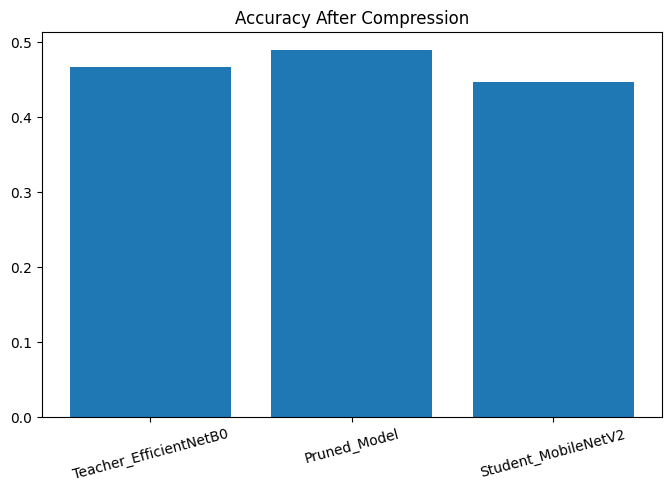

In [28]:
df_plot = df.dropna()

plt.figure(figsize=(8,5))

plt.bar(
    df_plot["Model"],
    df_plot["Accuracy"]
)

plt.xticks(rotation=15)

plt.title(
    "Accuracy After Compression"
)

plt.show()

**Cell 16: Model Size Reduction**

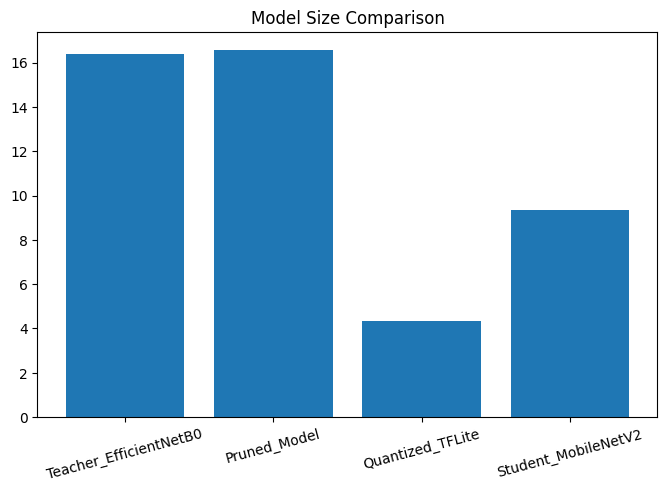

In [29]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Model"],
    df["Size_MB"]
)

plt.xticks(rotation=15)

plt.title(
    "Model Size Comparison"
)

plt.show()

**Cell 17: Energy Comparison**

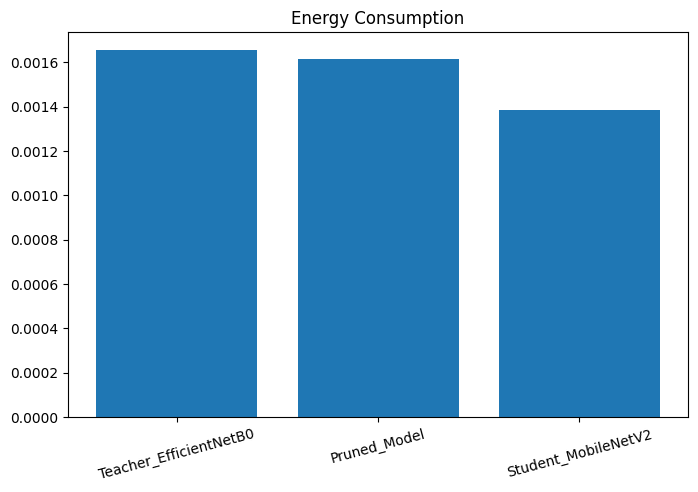

In [30]:
df_energy = df.dropna()

plt.figure(figsize=(8,5))

plt.bar(
    df_energy["Model"],
    df_energy["Energy"]
)

plt.xticks(rotation=15)

plt.title(
    "Energy Consumption"
)

plt.show()